<a href="https://colab.research.google.com/github/qhopark/titanic-ml-analysis/blob/main/Titanic_Predict_using_a_Bayesian_GraphNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a class="anchor" id="0"></a>
# Bayesian network for "Titanic: Machine Learning from Disaster"

<a class="anchor" id="0.1"></a>

## Table of Contents

1. [Import libraries](#1)
1. [Download datasets](#2)
1. [Creation the Bayesian network](#3)
1. [Inference from the Bayesian network](#4)
1. [Prediction](#5)

## 1. Import libraries <a class="anchor" id="1"></a>

[Back to Table of Contents](#0.1)

In [ ]:
!pip install bnlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 6.6 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=d0d82553452a5f6431d1a8b5e1fdb7c240bd5b141d368c529c851630c4d2b56a
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import bnlearn as bn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

## 2. Download datasets <a class="anchor" id="2"></a>

[Back to Table of Contents](#0.1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#df = pd.read_csv("/content/drive/MyDrive/titanic_train.csv")
# To display the top 5 rows
#df.head(5)

Mounted at /content/drive


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/titanic_train.csv').set_index('PassengerId')
test = pd.read_csv('/content/drive/MyDrive/titanic_test.csv').set_index('PassengerId')

In [ ]:
train.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Dropping columns with many unique values
drop_list = ['Name', 'Age', 'Cabin', 'Ticket', 'Fare']
train = train.drop(columns=drop_list)
test = test.drop(columns=drop_list)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Pclass    891 non-null    int64 
 2   Sex       891 non-null    object
 3   SibSp     891 non-null    int64 
 4   Parch     891 non-null    int64 
 5   Embarked  889 non-null    object
dtypes: int64(4), object(2)
memory usage: 48.7+ KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Pclass    418 non-null    int64 
 1   Sex       418 non-null    object
 2   SibSp     418 non-null    int64 
 3   Parch     418 non-null    int64 
 4   Embarked  418 non-null    object
dtypes: int64(3), object(2)
memory usage: 19.6+ KB


In [ ]:
# Data preparing
dfhot_train, dfnum_train = bn.df2onehot(train)
dfhot_test, dfnum_test = bn.df2onehot(test)

[df2onehot] WARNING use the standardized verbose status. The status [1-6] will be deprecated in future versions.
[df2onehot] WARNING use the standardized verbose status. The status [1-6] will be deprecated in future versions.


## 3. Creation the Bayesian network <a class="anchor" id="3"></a>

[Back to Table of Contents](#0.1)

In [ ]:
dfnum_train

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,1,2,1,3
1,1,1,0,2,1,1
2,1,3,0,1,1,3
3,1,1,0,2,1,3
4,0,3,1,1,1,3
...,...,...,...,...,...,...
886,0,2,1,1,1,3
887,1,1,0,1,1,3
888,0,3,0,2,3,3
889,1,1,1,1,1,1


In [ ]:
dfnum_target = dfnum_train.pop('Survived')

In [ ]:
Xtrain, Xval, Ztrain, Zval = train_test_split(dfnum_train, dfnum_target, test_size=0.2, random_state=0)
valid = pd.concat([Xval, Zval], axis='columns')
dfnum = pd.concat([Xtrain, Ztrain], axis='columns')
dfnum

,Pclass,Sex,SibSp,Parch,Embarked,Survived
140,3,0,1,3,1,0
439,2,1,1,1,3,0
817,2,1,2,2,1,0
378,3,1,1,1,1,0
491,3,1,1,1,3,0
...,...,...,...,...,...,...
835,1,0,2,2,1,1
192,3,0,2,1,3,1
629,3,1,1,1,2,0
559,3,0,2,1,3,1


In [ ]:
# Get score
def get_acc(model, df, col):
    # Get accuracy score by the model for the validation dataset df with target col
    pred = bn.predict(model, df, variables=[col])
    print(pred)
    acc = accuracy_score(df[col], pred[col])
    print('Accuracy -', acc)
    return acc

### Model 1

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


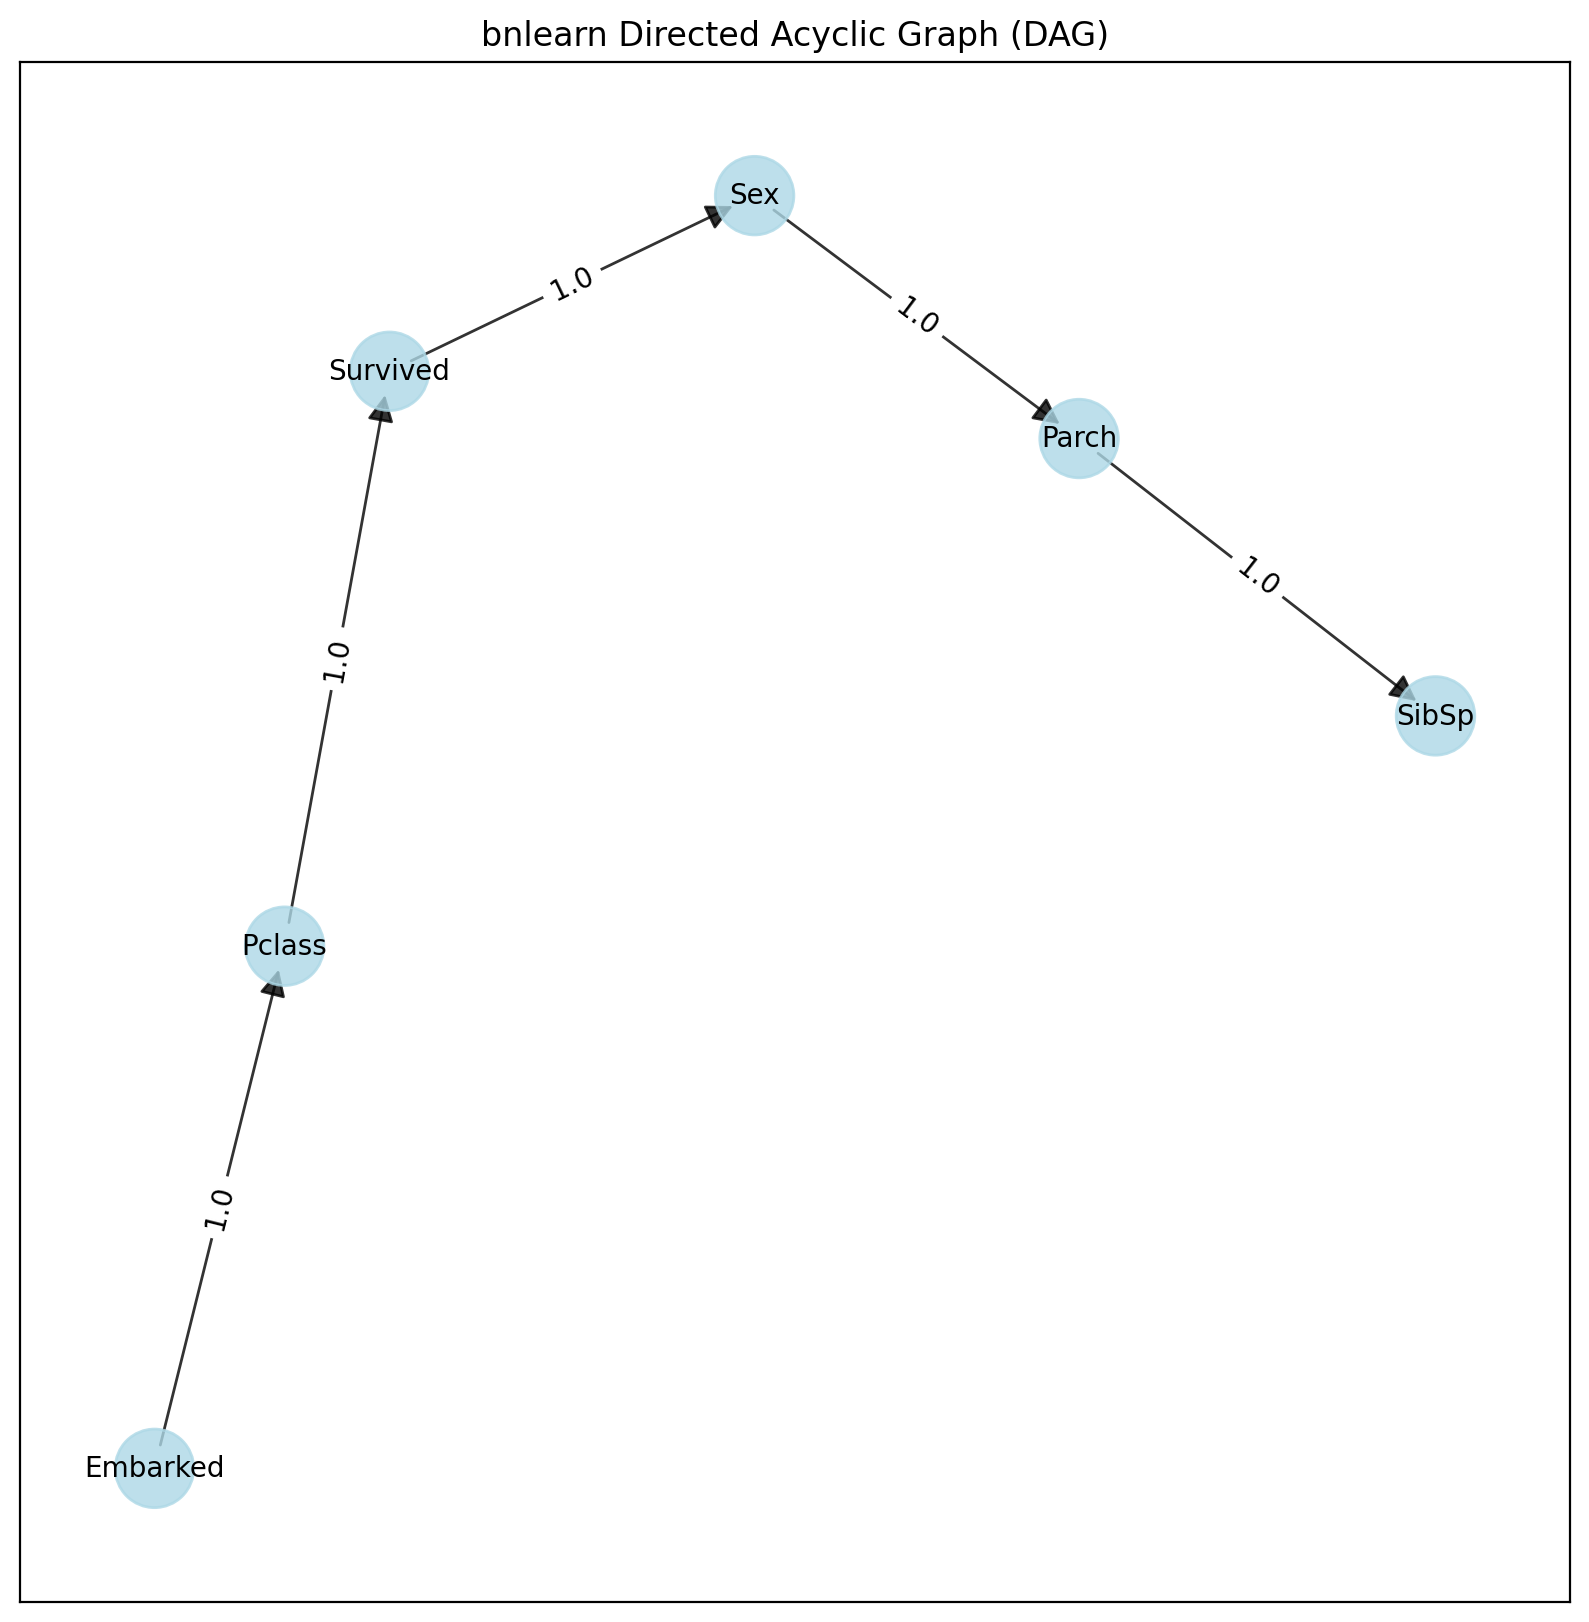

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of Pclass:
+-----------+---------------------+-----+---------------------+
| Embarked  | Embarked(0)         | ... | Embarked(3)         |
+-----------+---------------------+-----+---------------------+
| Pclass(1) | 0.3386243386243386  | ... | 0.24554541503694044 |
+-----------+---------------------+-----+---------------------+
| Pclass(2) | 0.33068783068783064 | ... | 0.27553237722729246 |
+-----------+---------------------+-----+---------------------+
| Pclass(3) | 0.33068783068783064 | ... | 0.47892220773576705 |
+-----------+---------------------+-----+---------------------+
[bnlearn] >CPD of Survived:
+-------------+--------------------+--------------------+--------------------+
| Pclass      | Pclass(1)          | Pclass(2)          | Pclass(3)          |
+-------------+---

In [ ]:
%%time
# Structure learning
DAG = bn.structure_learning.fit(dfnum, methodtype='hc', root_node='Survived', bw_list_method='nodes', verbose=3)

# Plot
G = bn.plot(DAG)

# Parameter learning
model = bn.parameter_learning.fit(DAG, dfnum, verbose=3);

In [ ]:
# About the model
model

{'model': <pgmpy.models.BayesianNetwork.BayesianNetwork at 0x79561528fda0>,
 'adjmat': target    Pclass    Sex  SibSp  Parch  Embarked  Survived
 source                                                   
 Pclass     False  False  False  False     False      True
 Sex        False  False  False   True     False     False
 SibSp      False  False  False  False     False     False
 Parch      False  False   True  False     False     False
 Embarked    True  False  False  False     False     False
 Survived   False   True  False  False     False     False,
 'config': {'verbose': 3, 'method': 'bayes', 'n_jobs': -1},
 'model_edges': [('Pclass', 'Survived'),
  ('Survived', 'Sex'),
  ('Sex', 'Parch'),
  ('Parch', 'SibSp'),
  ('Embarked', 'Pclass')],
 'structure_scores': {'k2': np.float64(-3174.9527427131247),
  'bic': np.float64(-3209.323591016362),
  'bdeu': np.float64(-3172.76499432183),
  'bds': np.float64(-3186.6279379330285)},
 'independence_test': None}

In [ ]:
# Get score of the model1
acc1 = get_acc(model, valid, 'Survived')

[bnlearn]> Remaining columns for inference: 5


100%|██████████| 59/59 [00:00<00:00, 865.34it/s]

     Survived         p
0           0  0.725084
1           0  0.725084
2           0  0.725084
3           1  0.662098
4           0  0.507407
..        ...       ...
174         0  0.507407
175         0  0.725084
176         1  0.662098
177         0  0.725084
178         0  0.725084

[179 rows x 2 columns]
Accuracy - 0.8156424581005587


### Model 2

[bnlearn] >Filter variables (nodes) on black_list..
[bnlearn] >Number of features after white/black listing: 5
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


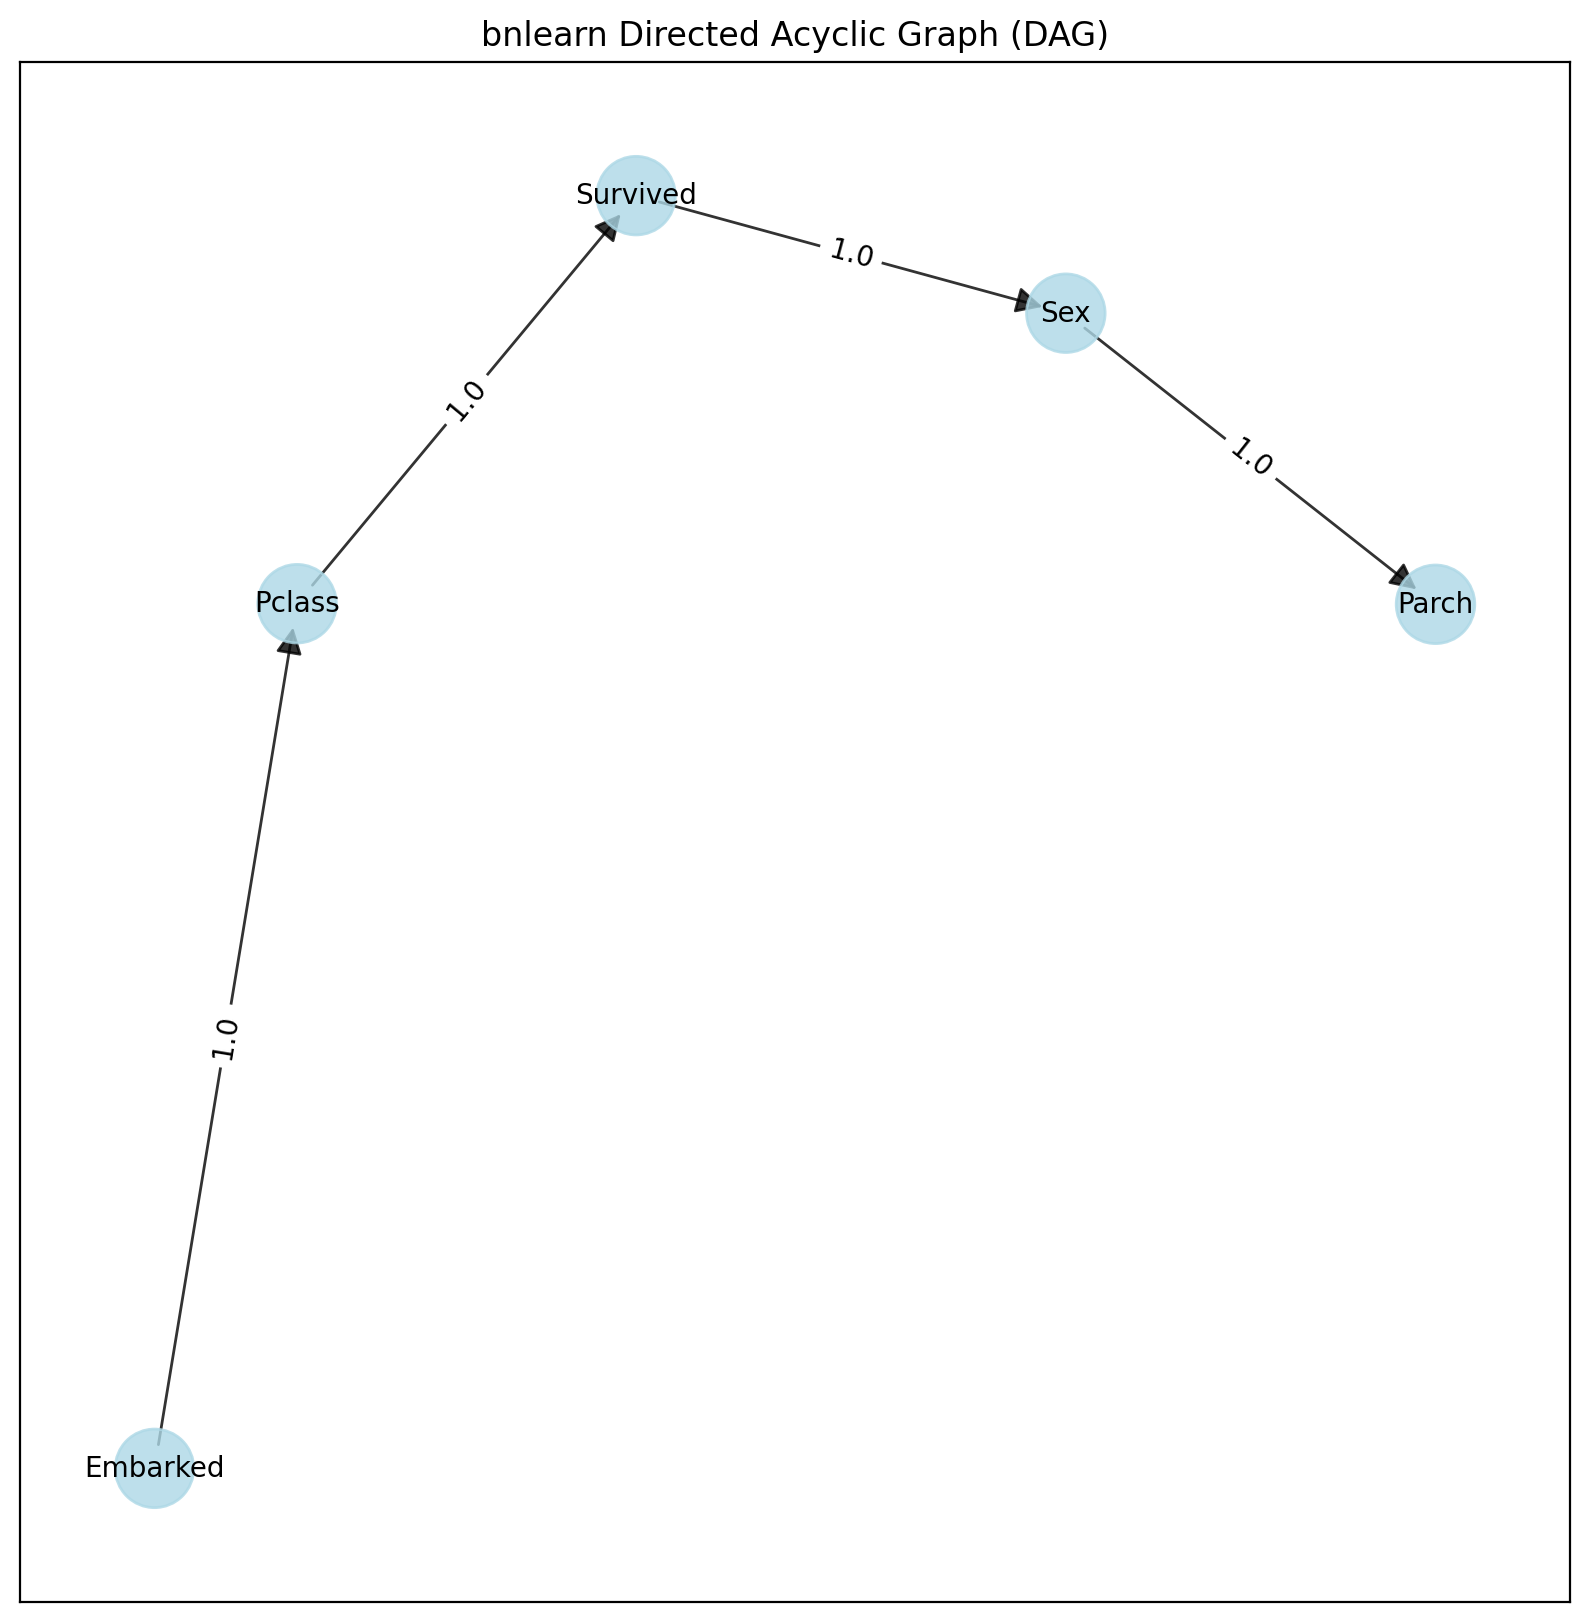

[bnlearn] >Removing columns from dataframe to make consistent with DAG [['SibSp']]
[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of Pclass:
+-----------+---------------------+-----+---------------------+
| Embarked  | Embarked(0)         | ... | Embarked(3)         |
+-----------+---------------------+-----+---------------------+
| Pclass(1) | 0.3386243386243386  | ... | 0.24554541503694044 |
+-----------+---------------------+-----+---------------------+
| Pclass(2) | 0.33068783068783064 | ... | 0.27553237722729246 |
+-----------+---------------------+-----+---------------------+
| Pclass(3) | 0.33068783068783064 | ... | 0.47892220773576705 |
+-----------+---------------------+-----+---------------------+
[bnlearn] >CPD of Survived:
+-------------+--------------------+--------------------+--------------------+
| Pclass      

In [ ]:
%%time
# Structure learning
DAG2 = bn.structure_learning.fit(dfnum, methodtype='hc', black_list=['SibSp'], root_node='Survived', bw_list_method='nodes', verbose=4)

# Plot
G2 = bn.plot(DAG2)

# Parameter learning
model2 = bn.parameter_learning.fit(DAG2, dfnum, verbose=4);

In [ ]:
# Score of the model2
acc2 = get_acc(model, valid.drop(columns=['SibSp']), 'Survived')

[bnlearn]> Remaining columns for inference: 4


100%|██████████| 34/34 [00:00<00:00, 848.21it/s]

     Survived         p
0           0  0.725084
1           0  0.725084
2           0  0.725084
3           1  0.662098
4           0  0.507407
..        ...       ...
174         0  0.507407
175         0  0.725084
176         1  0.662098
177         0  0.725084
178         0  0.725084

[179 rows x 2 columns]
Accuracy - 0.8156424581005587


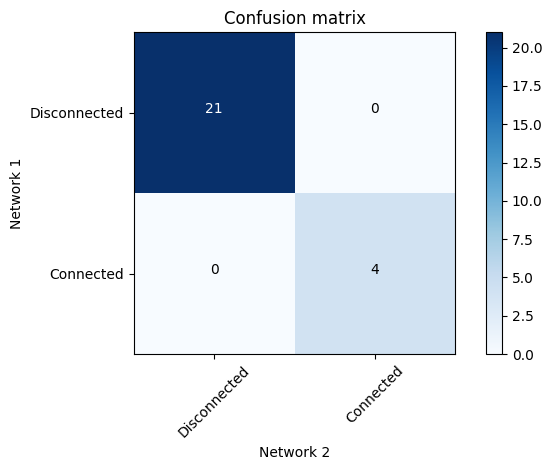

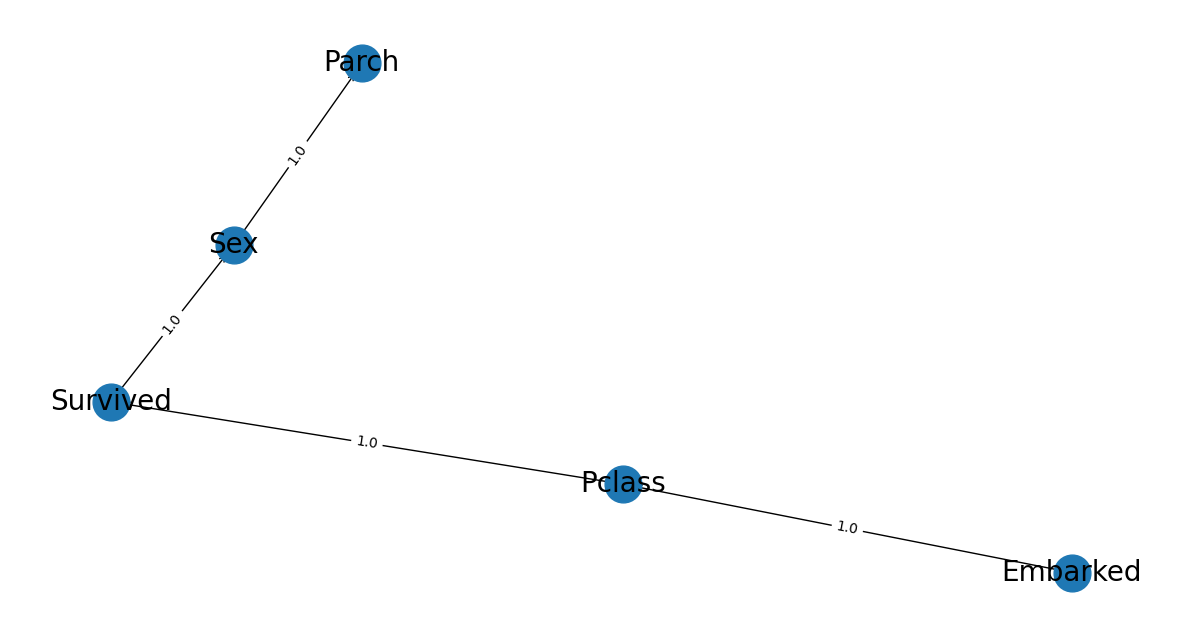

Coincidence - 1.0


In [ ]:
# Models comparing
res = bn.bnlearn.compare_networks(model, model2, figsize=(15, 8), verbose=3)
print('Coincidence -', (res[0][0, 0] + res[0][1, 1])/res[0].sum())

## 4. Inference from the Bayesian network <a class="anchor" id="4"></a>

[Back to Table of Contents](#0.1)

In [ ]:
%%time
# Make inference
query = bn.inference.fit(model, variables=['Survived'], evidence={'Sex':True, 'Pclass':True})
print(query)
print(query.df)

# Another inference using only sex for evidence
q1 = bn.inference.fit(model, variables=['Survived'], evidence={'Sex':0})
print(query)
print(query.df)

# Print model
bn.print_CPD(model)

[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.566487 |
+----+------------+----------+
|  1 |          1 | 0.433513 |
+----+------------+----------+

Summary for variables: ['Survived']
Given evidence: Sex=True, Pclass=True

Survived outcomes:
- Survived: 0 (56.6%)
- Survived: 1 (43.4%)
+-------------+-----------------+
| Survived    |   phi(Survived) |
+=============+=================+
| Survived(0) |          0.5665 |
+-------------+-----------------+
| Survived(1) |          0.4335 |
+-------------+-----------------+
   Survived         p
0         0  0.566487
1         1  0.433513
[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.419009 |
+----+------------+----------+
|  1 |          1 | 0.580991 |
+----+------------+----------+

Summary for variables: ['Survived']
Given evidence: Sex=

{'Pclass':     Pclass  Embarked         p
 0        1         0  0.338624
 1        1         1  0.383465
 2        1         2  0.268577
 3        1         3  0.245545
 4        2         0  0.330688
 5        2         1  0.259455
 6        2         2  0.274947
 7        2         3  0.275532
 8        3         0  0.330688
 9        3         1  0.357080
 10       3         2  0.456476
 11       3         3  0.478922,
 'Survived':    Survived  Pclass         p
 0         0       1  0.462252
 1         0       2  0.508345
 2         0       3  0.634369
 3         1       1  0.537748
 4         1       2  0.491655
 5         1       3  0.365631,
 'Sex':    Sex  Survived         p
 0    0         0  0.333333
 1    0         1  0.561449
 2    1         0  0.666667
 3    1         1  0.438551,
 'Parch':    Parch  Sex         p
 0      0    0  0.179384
 1      0    1  0.133679
 2      1    0  0.369478
 3      1    1  0.532642
 4      2    0  0.230254
 5      2    1  0.176166
 6      3  

## 5. Prediction <a class="anchor" id="5"></a>

[Back to Table of Contents](#0.1)

In [ ]:
# Prediction using the Bayesian network
Pout = bn.predict(model, df=dfnum_test, variables=['Survived'])
Pout

[bnlearn]> Remaining columns for inference: 5


100%|██████████| 84/84 [00:00<00:00, 827.58it/s]


,Survived,p
0,0,0.725084
1,0,0.507407
2,0,0.611161
3,0,0.725084
4,0,0.507407
...,...,...
413,0,0.725084
414,1,0.662098
415,0,0.725084
416,0,0.725084


In [ ]:
# Submission
submission = pd.read_csv('/content/drive/MyDrive/gender_submission.csv')
submission['Survived'] = Pout['Survived']
submission.to_csv('submission.csv', index=False)
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


[Go to Top](#0)

## Homework Questions

### Question 1: Bayesian Network Interpretation and Inference

1.  **Based on `model` (the first Bayesian network you created), identify the direct dependencies for the 'Survived' node.** (Hint: Look at `model['model_edges']` or visualize `G`).
2.  **Coding Challenge:** Using the `bnlearn.inference.fit` function and `model`, calculate the probability of survival (`Survived`) for the following two scenarios:
    *   **Scenario A:** A female passenger (`Sex=0`) in first class (`Pclass=1`).
    *   **Scenario B:** A male passenger (`Sex=1`) in third class (`Pclass=3`).
    Compare the probabilities and explain your observations based on the network structure.


In [ ]:
import bnlearn as bn

# your code here
model['model_edges']
[e for e in model['model_edges'] if 'Survived' in e]

A = bn.inference.fit(model, variables=['Survived'], evidence={'Sex':0, 'Pclass':1})
print(A.df)

B = bn.inference.fit(model, variables=['Survived'], evidence={'Sex':1, 'Pclass':3})
print(B.df)

[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.337902 |
+----+------------+----------+
|  1 |          1 | 0.662098 |
+----+------------+----------+

Summary for variables: ['Survived']
Given evidence: Sex=0, Pclass=1

Survived outcomes:
- Survived: 0 (33.8%)
- Survived: 1 (66.2%)
   Survived         p
0         0  0.337902
1         1  0.662098
[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.725084 |
+----+------------+----------+
|  1 |          1 | 0.274916 |
+----+------------+----------+

Summary for variables: ['Survived']
Given evidence: Sex=1, Pclass=3

Survived outcomes:
- Survived: 0 (72.5%)
- Survived: 1 (27.5%)
   Survived         p
0         0  0.725084
1         1  0.274916


The Bayesian network shows that Sex and Pclass have direct dependencies with Survived, so they directly influence the probability of survival. The inference results show that a female passenger in first class has much higher chance of survival compared to a male passenger in third class. I think that this is a fairly accurate reflection of the historical evacuation pattern of the Titanic, where women and higher class passengers were more likely to be prioritized.

### Question 2: Model Comparison and Evaluation

1.  **Recall the comparison between `model` and `model2`. What was the primary difference in how `model2` was constructed compared to `model`?** (Hint: Check the `black_list` parameter in `DAG2`'s creation).
2.  **Coding Challenge:** Re-run the accuracy calculation for `model2` using the `get_acc` function. Pay close attention to the `valid` DataFrame passed to `get_acc`. If the accuracies for `model` and `model2` are identical, explain why this might be the case given the differences in their construction. If they are different, explain why.


In [ ]:
#your code here
acc2 = get_acc(model2, valid.drop(columns=['SibSp']), 'Survived')
print(acc2)

[bnlearn]> Remaining columns for inference: 4


100%|██████████| 34/34 [00:00<00:00, 169.08it/s]

     Survived         p
0           0  0.725084
1           0  0.725084
2           0  0.725084
3           1  0.662098
4           0  0.507407
..        ...       ...
174         0  0.507407
175         0  0.725084
176         1  0.662098
177         0  0.725084
178         0  0.725084

[179 rows x 2 columns]
Accuracy - 0.8156424581005587
0.8156424581005587


Both models produced the same accuracy around 0.8156 which indicates that SibSp was not a significant variable in predicting survival, and that the network relied more on other variables such as Sex and Pclass, which are stronger predictors in the Titanic dataset.

D### Question 3: Feature Impact Visualization

1.  **Choose one categorical feature (other than 'Sex' or 'Pclass') from your processed `dfnum_train` dataset that you believe might have an impact on 'Survived'.**
2.  **Coding Challenge:** Using `bnlearn.inference.fit`, calculate the probability of survival for each unique category of your chosen feature, assuming all other relevant variables are unknown (i.e., only provide the chosen feature as evidence). Visualize these survival probabilities using a bar chart. Discuss whether your hypothesis about the feature's impact was supported by the results.

[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.557383 |
+----+------------+----------+
|  1 |          1 | 0.442617 |
+----+------------+----------+

Summary for variables: ['Survived']
Given evidence: Embarked=3

Survived outcomes:
- Survived: 0 (55.7%)
- Survived: 1 (44.3%)
[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.535671 |
+----+------------+----------+
|  1 |          1 | 0.464329 |
+----+------------+----------+

Summary for variables: ['Survived']
Given evidence: Embarked=1

Survived outcomes:
- Survived: 0 (53.6%)
- Survived: 1 (46.4%)
[bnlearn] >Variable Elimination.
+----+------------+----------+
|    |   Survived |        p |
+====+============+==========+
|  0 |          0 | 0.553492 |
+----+------------+----------+
|  1 |          1 | 0.446508 |
+----+------------+------

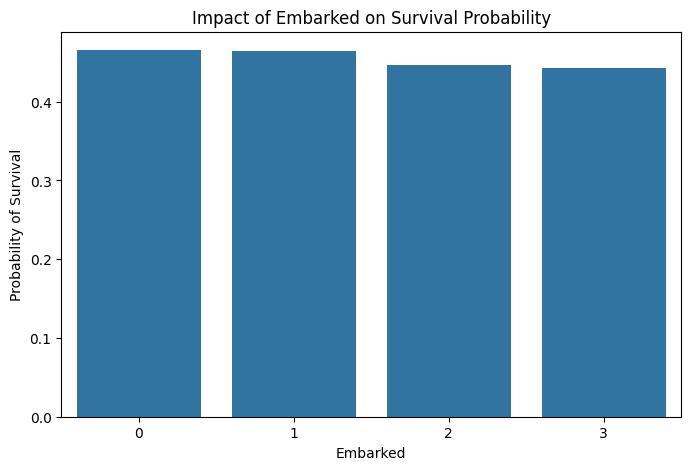

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Analyze impact of 'Embarked' on 'Survived'
# Replace 'Embarked' with your chosen feature if different
chosen_feature = 'Embarked'
unique_values = dfnum_train[chosen_feature].unique()

survival_probs = []
for value in unique_values:
    #<YOUR code here using bnlearn.infererence.fit>
    q = bn.inference.fit(model, variables=['Survived'], evidence={chosen_feature: value})

    prob_survive = q.df.loc[q.df['Survived'] == 1, 'p'].values[0]

    survival_probs.append(prob_survive)

results_df = pd.DataFrame({
    chosen_feature: unique_values,
    'Survival Probability': survival_probs
})

plt.figure(figsize=(8, 5))
###
###
#Your code here to visualize survival probabilities using a bar chart
sns.barplot(x=chosen_feature, y='Survival Probability', data=results_df)
plt.title(f"Impact of {chosen_feature} on Survival Probability")
plt.ylabel("Probability of Survival")
plt.xlabel(chosen_feature)
plt.show()

The bar chart shows that survival probabilities differ between embarkation locations, suggesting that the port of embarkation may have some influence on survival outcomes. This is possibly because passengers boarding from different ports belonged to different passenger classes or socioeconomic groups. Therefore, the hypothesis that Embarked has an impact on survival is supported by the results.